In [1]:
# ============================================================
# 1. Imports
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# Load the dataset
file_path = "Fina_SHIMP Data.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1", header=1)
df.head()  

,Demographic Info,Unnamed: 1,HIMP Run 1,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,HIMP Run 2,Unnamed: 9,...,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,SHIMP Run 2.1,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49
0,ID,Age/Sex,RL,LL,RA,LP,LA,RP,RL,LL,...,RA,LP,LA,RP,RL,LL,RA,LP,LA,RP
1,VSHIMP098,25/F,1.13,1.15,1.43,1.98,0.87,1.06,1.14,1.14,...,1.47,1.5,0.77,1.03,1.2,1.07,1.23,1.14,0.99,1.65
2,VSHIMP997,24/F,1.16,1.15,1.23,1.43,1.11,0.99,1.12,1.18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,VSHIMP_P001,22/F,1.02,1.04,1.61,1.36,0.9,0.97,1.03,1.09,...,1.56,1.1,1.04,1,1,0.98,0.72,0.96,1.29,1.39
4,VSHIMP002,23/F,1.15,1.09,1.3,1.35,1.13,1.16,1.09,1.13,...,1.03,1.25,0.89,1.16,0.89,0.92,0.84,1.08,1.14,1.22


In [3]:
df = pd.read_excel(file_path, sheet_name="Sheet1", header=2)
df.head()  

,ID,Age/Sex,RL,LL,RA,LP,LA,RP,RL.1,LL.1,...,RA.6,LP .1,LA.6,RP.6,RL.7,LL.7,RA.7,LP.5,LA.7,RP.7
0,VSHIMP098,25/F,1.13,1.15,1.43,1.98,0.87,1.06,1.14,1.14,...,1.47,1.50,0.77,1.03,1.20,1.07,1.23,1.14,0.99,1.65
1,VSHIMP997,24/F,1.16,1.15,1.23,1.43,1.11,0.99,1.12,1.18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,VSHIMP_P001,22/F,1.02,1.04,1.61,1.36,0.90,0.97,1.03,1.09,...,1.56,1.10,1.04,1.00,1.00,0.98,0.72,0.96,1.29,1.39
3,VSHIMP002,23/F,1.15,1.09,1.30,1.35,1.13,1.16,1.09,1.13,...,1.03,1.25,0.89,1.16,0.89,0.92,0.84,1.08,1.14,1.22
4,VSHIMP003,24/F,0.99,0.99,1.54,1.38,1.33,1.23,1.14,1.15,...,1.00,1.02,0.99,1.04,0.81,0.90,0.90,0.92,1.02,0.93


In [4]:
df.columns


Index(['ID', 'Age/Sex', 'RL', 'LL', 'RA', 'LP', 'LA', 'RP', 'RL.1', 'LL.1',
       'RA.1', 'LP.1', 'LA.1', 'RP.1', 'RL.2', 'LL.2', 'RA.2', 'LP ', 'LA.2',
       'RP.2', 'RL.3', 'LL.3', 'RA.3', 'LP.2', 'LA.3', 'RP.3', 'RL.4', 'LL.4',
       'RA.4', 'LP.3', 'LA.4', 'RP.4', 'RL.5', 'LL.5', 'RA.5', 'LP.4', 'LA.5',
       'RP.5', 'RL.6', 'LL.6', 'RA.6', 'LP .1', 'LA.6', 'RP.6', 'RL.7', 'LL.7',
       'RA.7', 'LP.5', 'LA.7', 'RP.7'],
      dtype='str')

In [5]:
# # parse HIMP data only
# canals = ["RL", "LL", "RA", "LP", "LA", "RP"]
# himp_blocks = {
#     ("W1", "Right"): range(2,8),
#     ("W1", "Left"): range(8,14),
#     ("W2", "Right"): range(26,32),
#     ("W2", "Left"): range(32,38),
# }
# records = []

# for i in range(3, len(df)):
#     participant_id = df.iloc[i, 0]
#     age_sex = df.iloc[i,1]

#     if pd.isna(participant_id):
#         continue
#     for (week, camera_side), cols in himp_blocks.items():
#         for canal, col in zip(canals, cols):
#             gain = df.iloc[i, col]

#             if pd.notna(gain):
#                 records.append({
#                     "participant_id": participant_id,
#                     "age_sex": age_sex,
#                     "week": week,
#                     "camera_side": camera_side,
#                     "canal": canal,
#                     "raw_himp_gain": gain
#                 })

# df_himp = pd.DataFrame(records)

# # split age_sex into separate age and sex columns
# age_sex_split = df_himp["age_sex"].astype(str).str.extract(r"^\s*(?P<age>\d{1,3})\s*[/\-]?\s*(?P<sex>[A-Za-z]+)\s*$")
# df_himp["age"] = pd.to_numeric(age_sex_split["age"], errors="coerce")
# df_himp["sex"] = age_sex_split["sex"].str.strip().str.upper().str[:1]
# df_himp.drop(columns=["age_sex"], inplace=True)
# df_himp

In [6]:
# ============================================================
# 3. Extract HIMP-only data
# ============================================================

canals = ["RL", "LL", "RA", "LP", "LA", "RP"]

himp_blocks = {
    ("W1", "Right"): range(2, 8),     # Week 1 HIMP Run 1 - Right camera
    ("W1", "Left"): range(8, 14),     # Week 1 HIMP Run 2 - Left camera
    ("W2", "Right"): range(26, 32),   # Week 2 HIMP Run 1 - Right camera
    ("W2", "Left"): range(32, 38),    # Week 2 HIMP Run 2 - Left camera
}

records = []

for i in range(3, len(df)):
    participant_id = df.iloc[i, 0]
    age_sex = df.iloc[i, 1]

    if pd.isna(participant_id):
        continue

    for (week, camera_side), cols in himp_blocks.items():
        for canal, col in zip(canals, cols):
            gain = df.iloc[i, col]

            if pd.notna(gain):
                records.append({
                    "participant_id": participant_id,
                    "age_sex": age_sex,
                    "week": week,
                    "camera_side": camera_side,
                    "canal": canal,
                    "raw_himp_gain": gain
                })

df_himp = pd.DataFrame(records)

df_himp["raw_himp_gain"] = pd.to_numeric(
    df_himp["raw_himp_gain"],
    errors="coerce"
)

df_himp = df_himp.dropna(subset=["raw_himp_gain"]).copy()

df_himp.head()

,participant_id,age_sex,week,camera_side,canal,raw_himp_gain
0,VSHIMP002,23/F,W1,Right,RL,1.15
1,VSHIMP002,23/F,W1,Right,LL,1.09
2,VSHIMP002,23/F,W1,Right,RA,1.30
3,VSHIMP002,23/F,W1,Right,LP,1.35
4,VSHIMP002,23/F,W1,Right,LA,1.13


In [7]:
# ============================================================
# 4. Add clinical/experimental features
# ============================================================

df_himp["canal_type"] = np.where(
    df_himp["canal"].isin(["RL", "LL"]),
    "Horizontal",
    "Vertical"
)

df_himp["inflated_pair_flag"] = np.where(
    ((df_himp["camera_side"] == "Right") & (df_himp["canal"].isin(["RA", "LP"]))) |
    ((df_himp["camera_side"] == "Left") & (df_himp["canal"].isin(["LA", "RP"]))),
    1,
    0
)

df_himp.head()

,participant_id,age_sex,week,camera_side,canal,raw_himp_gain,canal_type,inflated_pair_flag
0,VSHIMP002,23/F,W1,Right,RL,1.15,Horizontal,0
1,VSHIMP002,23/F,W1,Right,LL,1.09,Horizontal,0
2,VSHIMP002,23/F,W1,Right,RA,1.30,Vertical,1
3,VSHIMP002,23/F,W1,Right,LP,1.35,Vertical,1
4,VSHIMP002,23/F,W1,Right,LA,1.13,Vertical,0


In [8]:
# df_himp.drop(columns=df_himp.columns[1])

In [9]:
# # Feature engineering
# # if RL or LL => horizontal canal, else vertical
# df_himp["canal_type"] = np.where(df_himp["canal"].isin(["RL", "LL"]), "Horizontal", "Vertical")

# # inflate pairs: Right camera should have RA and LP, Left camera should have LA and RP
# # inflated_pair_flag = 1 if it's an inflated pair, else 0,
# # means we expect gain to be higher than 1 for these pairs due to camera placement bias
# # Right camera + RA/LP = inflated
# # Left camera + LA/RP = inflated
# df_himp["inflated_pair_flag"] = np.where(
#     ((df_himp["camera_side"] == "Right") & (df_himp["canal"].isin(["RA", "LP"]))) |
#     ((df_himp["camera_side"] == "Left") & (df_himp["canal"].isin(["LA", "RP"]))),
#     1, 0
# )
# df_himp['healthy_center'] = 1.0

# # ensure raw_himp_gain is numeric before subtracting
# df_himp["raw_himp_gain"] = pd.to_numeric(df_himp["raw_himp_gain"], errors="coerce")
# df_himp = df_himp.dropna(subset=["raw_himp_gain"]).copy()
# for col in ["week", "camera_side", "canal", "canal_type"]:
#     df_himp[col] = df_himp[col].fillna("Unknown")
# df_himp["inflated_pair_flag"] = df_himp["inflated_pair_flag"].fillna(0)
# df_himp["bias_from_1"] = df_himp["raw_himp_gain"] - df_himp["healthy_center"]
# df_himp


In [10]:
# ============================================================
# 5. Confirm Week 1 vs Week 2 stability
# ============================================================

from scipy.stats import ttest_ind

w1 = df_himp[df_himp["week"] == "W1"]["raw_himp_gain"]
w2 = df_himp[df_himp["week"] == "W2"]["raw_himp_gain"]

t_stat, p_val = ttest_ind(w1, w2)

print("T-statistic:", t_stat)
print("P-value:", p_val)

T-statistic: 1.3954855855449617
P-value: 0.16373441890604903


In [ ]:
# ============================================================
# 6. Create paired Right-vs-Left camera comparison
# ============================================================

paired = df_himp.pivot_table(
    index=["participant_id", "week", "canal"],
    columns="camera_side",
    values="raw_himp_gain"
).reset_index()

paired = paired.dropna(subset=["Right", "Left"]).copy()
paired.head()

camera_side,participant_id,week,canal,Left,Right
0,VSHIMP-D002,W1,LA,1.48,1.44
1,VSHIMP-D002,W1,LL,1.08,1.02
2,VSHIMP-D002,W1,LP,1.13,1.47
3,VSHIMP-D002,W1,RA,1.15,1.59
4,VSHIMP-D002,W1,RL,1.12,1.06


In [ ]:
# ============================================================
# 7. Calculate percentage inflation for vertical biased pairs
# ============================================================


records = []

for _, row in paired.iterrows():
    canal = row["canal"]
    right_gain = row["Right"]
    left_gain = row["Left"]

    if canal in ["RA", "LP"]:
        inflated_camera = "Right"
        inflated_gain = right_gain
        reference_gain = left_gain

    elif canal in ["LA", "RP"]:
        inflated_camera = "Left"
        inflated_gain = left_gain
        reference_gain = right_gain

    else:
        continue

    inflation_pct = (inflated_gain - reference_gain) / reference_gain

    records.append({
        "participant_id": row["participant_id"],
        "week": row["week"],
        "canal": canal,
        "inflated_camera": inflated_camera,
        "inflated_gain": inflated_gain,
        "reference_gain": reference_gain,
        "inflation_pct": inflation_pct
    })

inflation_df = pd.DataFrame(records)

inflation_df.head()

,participant_id,week,canal,inflated_camera,reference_camera,inflated_gain,reference_gain,inflation_pct
0,VSHIMP-D002,W1,LA,Left,Right,1.48,1.44,0.027778
1,VSHIMP-D002,W1,LP,Right,Left,1.47,1.13,0.300885
2,VSHIMP-D002,W1,RA,Right,Left,1.59,1.15,0.382609
3,VSHIMP-D002,W1,RP,Left,Right,1.72,1.31,0.312977
4,VSHIMP002,W1,LA,Left,Right,1.39,1.13,0.230088


In [ ]:
pattern_table = (
    inflation_df
    .groupby(["inflated_camera", "canal"])
    .agg(
        mean_inflation_pct=("inflation_pct", "mean"),
        median_inflation_pct=("inflation_pct", "median"),
        std_inflation_pct=("inflation_pct", "std"),
        n=("inflation_pct", "count")
    )
    .reset_index()
)

pattern_table["mean_inflation_pct_display"] = pattern_table["mean_inflation_pct"] * 100

pattern_table

In [13]:
# ============================================================
# 8. Summarize learned inflation percentages
# ============================================================

inflation_summary = inflation_df.groupby(
    ["inflated_camera", "canal"]
)["inflation_pct"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
    min="min",
    max="max"
).reset_index()

inflation_summary["mean_pct"] = inflation_summary["mean"] * 100
inflation_summary["median_pct"] = inflation_summary["median"] * 100

inflation_summary

,inflated_camera,canal,count,mean,median,std,min,max,mean_pct,median_pct
0,Left,LA,30,0.225397,0.298879,0.231459,-0.321918,0.573770,22.539707,29.887914
1,Left,RP,30,0.224385,0.169155,0.226774,-0.301676,0.619048,22.438451,16.915465
2,Right,LP,30,0.078424,0.088053,0.120628,-0.226415,0.300885,7.842397,8.805332
3,Right,RA,30,0.148909,0.134563,0.165409,-0.213333,0.600000,14.890943,13.456288


In [14]:
# # baseline summary before correction
# summary_before = df_himp.groupby(["camera_side", "canal"])["raw_himp_gain"].agg(
#     count="count",
#     mean="mean",
#     std="std",
#     min="min",
#     max="max"
# ).reset_index()

# summary_before

In [15]:
# ============================================================
# 9. Prepare ML model to predict inflation percentage
# ============================================================

features = ["canal", "inflated_camera", "inflated_gain"]
target = "inflation_pct"

X = inflation_df[features]
y = inflation_df[target]
groups = inflation_df["participant_id"]

numeric_features = ["inflated_gain"]
categorical_features = ["canal", "inflated_camera"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

inflation_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge(alpha=1.0))
])

In [16]:
# # define ML target
# # we are not forcing gain to exactly 1, but rather trying to predict the bias from 1, 
# # which allows for more flexibility in the model and accounts for natural variability in healthy individuals. 
# # The target variable is "bias_from_1", which represents how much the raw HIMP gain deviates from 
# # the ideal healthy center of 1. This way, the model can learn to predict both positive and negative deviations, 
# # rather than being constrained to only predict values that would correct to exactly 1. 
# # This approach is more realistic and can capture a wider range of potential outcomes in the data.


# target = "bias_from_1"
# features = [
#     "raw_himp_gain",
#     #"week",
#     "camera_side",
#     "canal",
#     "canal_type",
#     "inflated_pair_flag",
# ]

# X = df_himp[features]
# y = df_himp[target]

# groups = df_himp["participant_id"]


In [17]:
# ============================================================
# 10. Cross-validation by participant
# ============================================================

cv = GroupKFold(n_splits=5)

mae_scores = -cross_val_score(
    inflation_model,
    X,
    y,
    cv=cv,
    groups=groups,
    scoring="neg_mean_absolute_error"
)

print("Inflation percentage CV MAE scores:", mae_scores)
print("Mean Inflation percentage CV MAE:", mae_scores.mean())
print("Mean Inflation percentage CV MAE (%):", mae_scores.mean() * 100)

Inflation percentage CV MAE scores: [0.1255915  0.11945272 0.07863807 0.13469814 0.09292423]
Mean Inflation percentage CV MAE: 0.11026093129956054
Mean Inflation percentage CV MAE (%): 11.026093129956054


In [18]:
# ============================================================
# 11. Train final model and predict inflation percentage
# ============================================================

inflation_model.fit(X, y)

inflation_df["predicted_inflation_pct"] = inflation_model.predict(X)

# Prevent negative correction
inflation_df["predicted_inflation_pct"] = inflation_df["predicted_inflation_pct"].clip(lower=0)

inflation_df["corrected_gain"] = (
    inflation_df["inflated_gain"] / (1 + inflation_df["predicted_inflation_pct"])
)

inflation_df.head()

,participant_id,week,canal,inflated_camera,reference_camera,inflated_gain,reference_gain,inflation_pct,predicted_inflation_pct,corrected_gain
0,VSHIMP-D002,W1,LA,Left,Right,1.48,1.44,0.027778,0.234268,1.199091
1,VSHIMP-D002,W1,LP,Right,Left,1.47,1.13,0.300885,0.184481,1.241050
2,VSHIMP-D002,W1,RA,Right,Left,1.59,1.15,0.382609,0.296360,1.226511
3,VSHIMP-D002,W1,RP,Left,Right,1.72,1.31,0.312977,0.383493,1.243230
4,VSHIMP002,W1,LA,Left,Right,1.39,1.13,0.230088,0.165046,1.193086


In [19]:
# ============================================================
# 12. Evaluate correction against paired reference camera value
# ============================================================

before_mae = mean_absolute_error(
    inflation_df["reference_gain"],
    inflation_df["inflated_gain"]
)

after_mae = mean_absolute_error(
    inflation_df["reference_gain"],
    inflation_df["corrected_gain"]
)

before_rmse = mean_squared_error(
    inflation_df["reference_gain"],
    inflation_df["inflated_gain"]
) ** 0.5

after_rmse = mean_squared_error(
    inflation_df["reference_gain"],
    inflation_df["corrected_gain"]
) ** 0.5

improvement_pct = (before_mae - after_mae) / before_mae * 100

print("Before correction MAE vs reference:", before_mae)
print("After correction MAE vs reference:", after_mae)
print("Before correction RMSE vs reference:", before_rmse)
print("After correction RMSE vs reference:", after_rmse)
print("Improvement %:", improvement_pct)

Before correction MAE vs reference: 0.24466666666666667
After correction MAE vs reference: 0.11516633383644788
Before correction RMSE vs reference: 0.30452695556660775
After correction RMSE vs reference: 0.16888780610541637
Improvement %: 52.929291347500865


In [20]:
# ============================================================
# 13. Canal-level correction summary
# ============================================================

canal_eval = inflation_df.groupby(["inflated_camera", "canal"]).apply(
    lambda x: pd.Series({
        "inflated_mean_gain": x["inflated_gain"].mean(),
        "reference_mean_gain": x["reference_gain"].mean(),
        "corrected_mean_gain": x["corrected_gain"].mean(),
        "actual_inflation_pct_mean": x["inflation_pct"].mean() * 100,
        "predicted_inflation_pct_mean": x["predicted_inflation_pct"].mean() * 100,
        "before_mae_vs_reference": np.mean(np.abs(x["inflated_gain"] - x["reference_gain"])),
        "after_mae_vs_reference": np.mean(np.abs(x["corrected_gain"] - x["reference_gain"])),
        "n": len(x)
    })
).reset_index()

canal_eval

,inflated_camera,canal,inflated_mean_gain,reference_mean_gain,corrected_mean_gain,actual_inflation_pct_mean,predicted_inflation_pct_mean,before_mae_vs_reference,after_mae_vs_reference,n
0,Left,LA,1.466000,1.229333,1.190981,22.539707,22.839271,0.319333,0.175274,30.0
1,Left,RP,1.514667,1.258333,1.231456,22.438451,22.845534,0.308333,0.111771,30.0
2,Right,LP,1.333000,1.244333,1.227337,7.842397,8.528476,0.142000,0.086769,30.0
3,Right,RA,1.398333,1.225333,1.203788,14.890943,15.916489,0.209000,0.086851,30.0


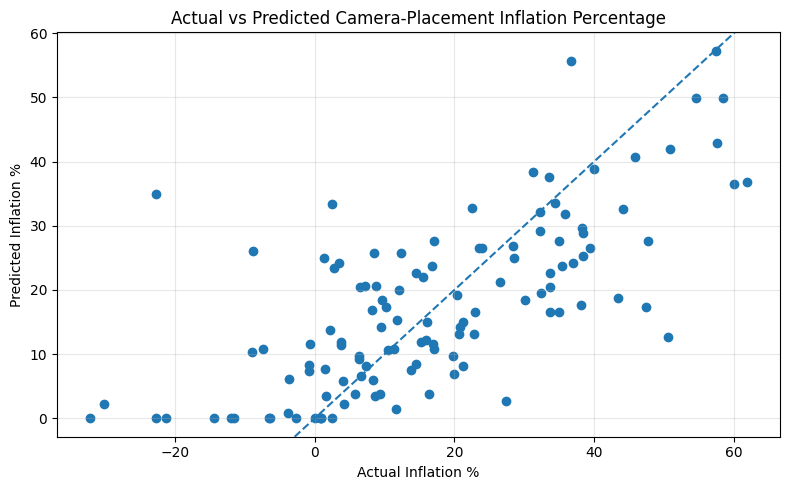

In [21]:
# ============================================================
# 14. Plot actual vs predicted inflation percentage
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    inflation_df["inflation_pct"] * 100,
    inflation_df["predicted_inflation_pct"] * 100
)

plt.axline((0, 0), slope=1, linestyle="--")

plt.xlabel("Actual Inflation %")
plt.ylabel("Predicted Inflation %")
plt.title("Actual vs Predicted Camera-Placement Inflation Percentage")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

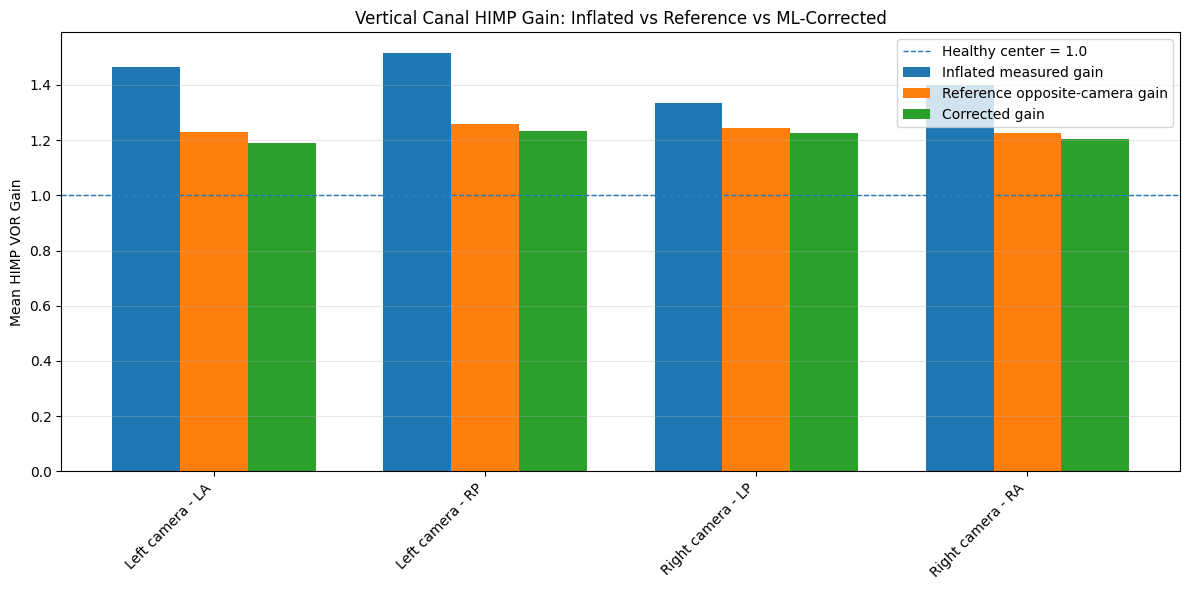

In [22]:
# ============================================================
# 15. Bar chart: before/reference/after by canal
# ============================================================

plot_summary = canal_eval.copy()

plot_summary["label"] = (
    plot_summary["inflated_camera"] + " camera - " + plot_summary["canal"]
)

x = np.arange(len(plot_summary))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(
    x - width,
    plot_summary["inflated_mean_gain"],
    width,
    label="Inflated measured gain"
)

plt.bar(
    x,
    plot_summary["reference_mean_gain"],
    width,
    label="Reference opposite-camera gain"
)

plt.bar(
    x + width,
    plot_summary["corrected_mean_gain"],
    width,
    label="Corrected gain"
)

plt.axhline(1.0, linestyle="--", linewidth=1, label="Healthy center = 1.0")

plt.xticks(x, plot_summary["label"], rotation=45, ha="right")
plt.ylabel("Mean HIMP VOR Gain")
plt.title("Vertical Canal HIMP Gain: Inflated vs Reference vs ML-Corrected")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

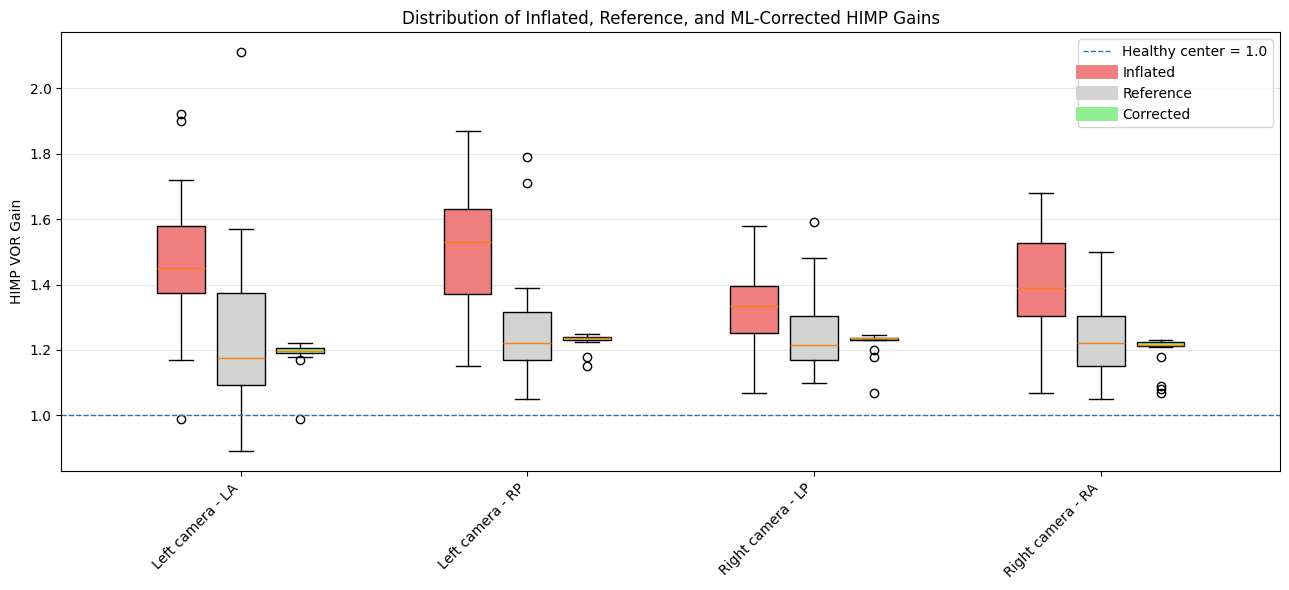

In [23]:
# ============================================================
# 16. Boxplot before vs after by canal-camera pair
# ============================================================

box_df = inflation_df.melt(
    id_vars=["participant_id", "week", "canal", "inflated_camera"],
    value_vars=["inflated_gain", "corrected_gain", "reference_gain"],
    var_name="gain_type",
    value_name="gain"
)

box_df["label"] = box_df["inflated_camera"] + " camera - " + box_df["canal"]

box_df["gain_type"] = box_df["gain_type"].map({
    "inflated_gain": "Inflated",
    "reference_gain": "Reference",
    "corrected_gain": "Corrected"
})

labels = sorted(box_df["label"].unique())

fig, ax = plt.subplots(figsize=(13, 6))

positions = []
data = []
tick_positions = []
tick_labels = []

offsets = [-0.25, 0, 0.25]
gain_types = ["Inflated", "Reference", "Corrected"]

for i, label in enumerate(labels):
    base = i * 1.2
    tick_positions.append(base)
    tick_labels.append(label)

    for offset, gain_type in zip(offsets, gain_types):
        positions.append(base + offset)
        data.append(
            box_df[
                (box_df["label"] == label) &
                (box_df["gain_type"] == gain_type)
            ]["gain"].dropna()
        )

bp = ax.boxplot(
    data,
    positions=positions,
    widths=0.2,
    patch_artist=True
)

colors = []
for i in range(len(labels)):
    colors.extend(["lightcoral", "lightgray", "lightgreen"])

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

ax.axhline(1.0, linestyle="--", linewidth=1, label="Healthy center = 1.0")

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha="right")
ax.set_ylabel("HIMP VOR Gain")
ax.set_title("Distribution of Inflated, Reference, and ML-Corrected HIMP Gains")

ax.plot([], [], color="lightcoral", linewidth=10, label="Inflated")
ax.plot([], [], color="lightgray", linewidth=10, label="Reference")
ax.plot([], [], color="lightgreen", linewidth=10, label="Corrected")

ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# 17. Function for new patient prediction
# ============================================================

def correct_new_himp_gain(raw_gain, camera_side, canal):
    """
    Corrects HIMP gain using learned percentage inflation.
    
    This does NOT force gain toward 1.0.
    It removes estimated camera-placement inflation proportionally.
    """

    inflated_pair = (
        ((camera_side == "Right") and (canal in ["RA", "LP"])) or
        ((camera_side == "Left") and (canal in ["LA", "RP"]))
    )

    if not inflated_pair:
        return {
            "raw_gain": raw_gain,
            "camera_side": camera_side,
            "canal": canal,
            "predicted_inflation_pct": 0.0,
            "corrected_gain": raw_gain,
            "message": "No major camera-placement inflation pattern expected for this canal-camera pair."
        }

    input_df = pd.DataFrame([{
        "canal": canal,
        "inflated_camera": camera_side,
        "inflated_gain": raw_gain
    }])

    pred_pct = inflation_model.predict(input_df)[0]

    # Avoid negative correction
    pred_pct = max(pred_pct, 0)

    corrected_gain = raw_gain / (1 + pred_pct)

    return {
        "raw_gain": raw_gain,
        "camera_side": camera_side,
        "canal": canal,
        "predicted_inflation_pct": pred_pct,
        "predicted_inflation_pct_display": pred_pct * 100,
        "corrected_gain": corrected_gain,
        "message": "Known inflated vertical camera-canal pattern corrected using proportional percentage adjustment."
    }

In [25]:
# ============================================================
# 18. Test new patient examples
# ============================================================

example_1 = correct_new_himp_gain(
    raw_gain=0.80,
    camera_side="Right",
    canal="RA"
)

example_1

{'raw_gain': 0.8,
 'camera_side': 'Right',
 'canal': 'RA',
 'predicted_inflation_pct': 0,
 'predicted_inflation_pct_display': 0,
 'corrected_gain': 0.8,
 'message': 'Known inflated vertical camera-canal pattern corrected using proportional percentage adjustment.'}

In [26]:
example_2 = correct_new_himp_gain(
    raw_gain=1.40,
    camera_side="Right",
    canal="RA"
)

example_2

{'raw_gain': 1.4,
 'camera_side': 'Right',
 'canal': 'RA',
 'predicted_inflation_pct': np.float64(0.15022389139022418),
 'predicted_inflation_pct_display': np.float64(15.022389139022419),
 'corrected_gain': np.float64(1.2171543388025807),
 'message': 'Known inflated vertical camera-canal pattern corrected using proportional percentage adjustment.'}

In [27]:
example_3 = correct_new_himp_gain(
    raw_gain=0.95,
    camera_side="Left",
    canal="LA"
)

example_3

{'raw_gain': 0.95,
 'camera_side': 'Left',
 'canal': 'LA',
 'predicted_inflation_pct': 0,
 'predicted_inflation_pct_display': 0,
 'corrected_gain': 0.95,
 'message': 'Known inflated vertical camera-canal pattern corrected using proportional percentage adjustment.'}

In [28]:
example_4 = correct_new_himp_gain(
    raw_gain=1.05,
    camera_side="Right",
    canal="RL"
)

example_4

{'raw_gain': 1.05,
 'camera_side': 'Right',
 'canal': 'RL',
 'predicted_inflation_pct': 0.0,
 'corrected_gain': 1.05,
 'message': 'No major camera-placement inflation pattern expected for this canal-camera pair.'}

In [29]:
# ============================================================
# 19. Save model bundle
# ============================================================

model_bundle = {
    "model": inflation_model,
    "features": features,
    "model_type": "percentage_inflation_calibration",
    "correction_formula": "corrected_gain = raw_gain / (1 + predicted_inflation_pct)",
    "inflated_patterns": {
        "Right": ["RA", "LP"],
        "Left": ["LA", "RP"]
    }
}

joblib.dump(model_bundle, "himp_percentage_inflation_model.pkl")

print("Saved model: himp_percentage_inflation_model.pkl")

Saved model: himp_percentage_inflation_model.pkl


In [30]:
# X

In [31]:
# # target variable = bias_from_1
# y

In [32]:
# groups

In [33]:
# # Build Ridge Regression Model
# numeric_features = ["raw_himp_gain", "inflated_pair_flag"]
# categorical_features = [#"week",
#                          "camera_side", "canal", "canal_type"]

# numeric_transformer = Pipeline(steps=[
#     ("imputer", SimpleImputer(strategy="median")),
#     ("scaler", StandardScaler())
# ])

# categorical_transformer = Pipeline(steps=[
#     ("imputer", SimpleImputer(strategy="most_frequent")),
#     ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
# ])

# preprocess = ColumnTransformer(
#     transformers=[
#         ("num", numeric_transformer, numeric_features),
#         ("cat", categorical_transformer, categorical_features)
#     ]
# )

# ridge_model = Pipeline(steps=[
#     ("preprocess", preprocess),
#     ("model", Ridge(alpha=1.0))
# ])

In [34]:
# # Cross validation for participant-level data
# cv = GroupKFold(n_splits=5)
# mae_scores = -cross_val_score(
#     ridge_model, X, y, 
#     groups=groups, 
#     cv=cv,
#     scoring="neg_mean_absolute_error")

In [35]:
# print("Ridge CV MAE:", mae_scores)
# print("Mean Ridge CV MAE:", mae_scores.mean())

In [36]:
# # Train model ridge
# ridge_model.fit(X,y)
# df_himp["predicted_bias"] = ridge_model.predict(X)

# # soft correction approachL remove only 80% of the predicted bias, 
# # which allows for a more gradual correction and accounts for potential model imperfections.
# correction_strength = 0.80

# df_himp["corrected_himp_gain"] = df_himp["raw_himp_gain"] - correction_strength * df_himp["predicted_bias"]

# # safety check optional to avoid unrealistic corrections
# df_himp["corrected_himp_gain"] = df_himp["corrected_himp_gain"].clip(lower=0.65, upper=1.35)
# df_himp.head()

In [37]:
# # Evaluate before vs after correction
# before_mae = mean_absolute_error(df_himp["healthy_center"], df_himp["raw_himp_gain"])
# after_mae = mean_absolute_error(df_himp["healthy_center"], df_himp["corrected_himp_gain"])

# before_rmse = mean_squared_error(df_himp["healthy_center"], df_himp["raw_himp_gain"]) ** 0.5
# after_rmse = mean_squared_error(df_himp["healthy_center"], df_himp["corrected_himp_gain"]) ** 0.5

# print(f"Before Correction - MAE: {before_mae:.4f}, RMSE: {before_rmse:.4f}")
# print(f"After Correction - MAE: {after_mae:.4f}, RMSE: {after_rmse:.4f}")
# print("Before RMSE from 1.0: ", before_rmse)
# print("After RMSE from 1.0: ", after_rmse)
# print("Improvement %", (before_mae - after_mae) / before_mae * 100)

In [38]:
# # canal-level evaluation

# canal_eval = df_himp.groupby("canal").apply(lambda x: pd.Series({
#     "before_mae_gain": x["raw_himp_gain"].mean(),
#     "after_mae_gain": x["corrected_himp_gain"].mean(),
#     "before_mae_from_1": np.mean(np.abs(np.abs(x["raw_himp_gain"] - 1.0))),
#     "after_mae_from_1": np.mean(np.abs(np.abs(x["corrected_himp_gain"] - 1.0))),
#     "n": len(x)
# })).reset_index()
# canal_eval

In [39]:
# # 12. Camera-placement effect before vs after

# placement_eval = df_himp.groupby(["camera_side", "canal"]).agg(
#     before_mean=("raw_himp_gain", "mean"),
#     after_mean=("corrected_himp_gain", "mean"),
#     n=("raw_himp_gain", "count")
# ).reset_index()

# placement_eval

In [40]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Create plotting dataframe
# plot_df = df_himp.melt(
#     id_vars=["participant_id", 
#              #"week", 
#              "camera_side", "canal"],
#     value_vars=["raw_himp_gain", "corrected_himp_gain"],
#     var_name="gain_type",
#     value_name="gain"
# )

# # Order canals properly
# canal_order = ["RL", "LL", "RA", "LP", "LA", "RP"]

# fig, ax = plt.subplots(figsize=(12, 6))

# x = np.arange(len(canal_order))
# width = 0.35

# before_data = [
#     plot_df[
#         (plot_df["canal"] == canal) &
#         (plot_df["gain_type"] == "raw_himp_gain")
#     ]["gain"]
#     for canal in canal_order
# ]

# after_data = [
#     plot_df[
#         (plot_df["canal"] == canal) &
#         (plot_df["gain_type"] == "corrected_himp_gain")
#     ]["gain"]
#     for canal in canal_order
# ]

# # Before correction
# bp1 = ax.boxplot(
#     before_data,
#     positions=x - width/2,
#     widths=0.3,
#     patch_artist=True
# )

# # After correction
# bp2 = ax.boxplot(
#     after_data,
#     positions=x + width/2,
#     widths=0.3,
#     patch_artist=True
# )

# # Colors
# for patch in bp1['boxes']:
#     patch.set_facecolor('lightblue')

# for patch in bp2['boxes']:
#     patch.set_facecolor('lightgreen')

# # Labels and formatting
# ax.set_xticks(x)
# ax.set_xticklabels(canal_order, fontsize=11)

# ax.axhline(1.0, linestyle="--", linewidth=1)

# ax.set_ylabel("HIMP VOR Gain", fontsize=12)
# ax.set_xlabel("Canal", fontsize=12)

# ax.set_title("HIMP Gain Before vs After ML Calibration", fontsize=14)

# # Manual legend
# ax.plot([], [], color='lightblue', linewidth=10, label='Before Correction')
# ax.plot([], [], color='lightgreen', linewidth=10, label='After Correction')

# ax.legend()

# plt.tight_layout()
# plt.show()

In [41]:
# # 14. Save corrected dataset

# output_path = "himp_ml_corrected_results.csv"
# df_himp.to_csv(output_path, index=False)

# print("Saved:", output_path)

In [42]:
# week_analysis = df_himp.groupby("week")["raw_himp_gain"].agg(
#     mean="mean",
#     std="std",
#     count="count"
# )

# print(week_analysis)

In [43]:
# from scipy.stats import ttest_ind

# w1 = df_himp[df_himp["week"] == "W1"]["raw_himp_gain"]
# w2 = df_himp[df_himp["week"] == "W2"]["raw_himp_gain"]

# t_stat, p_val = ttest_ind(w1, w2)

# print("T-statistic:", t_stat)
# print("P-value:", p_val)

In [44]:
# import joblib

# model_bundle = {
#     "model": ridge_model,
#     "features": [
#         "raw_himp_gain",
#         "camera_side",
#         "canal",
#         "canal_type",
#         "inflated_pair_flag"
#     ],
#     "correction_strength": 0.80
# }

# joblib.dump(model_bundle, "himp_ridge_calibration_model.pkl")
# print("Model saved.")

In [45]:
# import matplotlib.pyplot as plt
# import numpy as np

# canal_order = ["RL", "LL", "RA", "LP", "LA", "RP"]
# camera_order = ["Right", "Left"]

# summary_plot = (
#     df_himp
#     .groupby(["camera_side", "canal"])
#     .agg(
#         before_mean=("raw_himp_gain", "mean"),
#         after_mean=("corrected_himp_gain", "mean")
#     )
#     .reset_index()
# )

# for camera in camera_order:
#     temp = summary_plot[summary_plot["camera_side"] == camera].copy()
#     temp["canal"] = pd.Categorical(temp["canal"], categories=canal_order, ordered=True)
#     temp = temp.sort_values("canal")

#     x = np.arange(len(canal_order))
#     width = 0.35

#     fig, ax = plt.subplots(figsize=(11, 5))

#     ax.bar(
#         x - width/2,
#         temp["before_mean"],
#         width,
#         label="Before correction"
#     )

#     ax.bar(
#         x + width/2,
#         temp["after_mean"],
#         width,
#         label="After correction"
#     )

#     ax.axhline(1.0, linestyle="--", linewidth=1, label="Healthy center = 1.0")

#     ax.set_title(f"HIMP Gain Before vs After ML Calibration - {camera} Camera")
#     ax.set_xlabel("Canal")
#     ax.set_ylabel("Mean HIMP VOR Gain")
#     ax.set_xticks(x)
#     ax.set_xticklabels(canal_order)

#     ax.legend()
#     ax.grid(axis="y", alpha=0.3)

#     plt.tight_layout()
#     plt.show()